In [1]:
import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


In [ ]:
from tools import read_data, rebin_data, get_observable_and_likelihood, run_profiler, run_mcmc, plot_triangle

In [ ]:
from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[000000.00] [0/1] 04-27 14:18  FIT PNG                   INFO     Load data from: /Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded and mocks from: /Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/


In [4]:
def propose_fiducial():
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmax': 0.08, 'kmax_ell2': 0.08}
    
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmax': 0.08, 'kmax_ell2': 0.08}

    return propose_fiducial

fiducial = propose_fiducial()

In [5]:
tracer = 'QSO'

pk, window, _, mocks = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, add_ic=True, 
                                   aladr1=False, weight_type_mocks='default-fkp-oqe', **fiducial[tracer])

zeffs = {}
zeffs['QSOxQSO'] = {ell: window.observable.get(ell).attrs['zeff'] for ell in pk.ells}

kmin = 3e-3

chains = []

for kpivot, nrebin in zip([[1e-2, 2e-2], [2e-2], [1e-2, 2e-2]], [[2,2], [4], [2, 4]]):
    logger.info(f'Running rebinning with kpivot={kpivot} and nrebin={nrebin}')

    pk_t, window_t, _, mocks_t = rebin_data(pk, window, None, mocks, tracer=tracer, kpivot=kpivot, nrebin=nrebin, kmin=kmin, kmin_ell2=kmin, **fiducial['QSO'])
    try: 
        logger.info(f'After rebinning and k range selection: {pk_t.get(0).k.shape[0]} and {pk_t.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk_t.get(0).k.shape[0]} data points.')

    observable, likelihood = get_observable_and_likelihood(pk_t, window_t, mocks_t, tracer, zeffs, engine='camb')
    profiler = run_profiler(likelihood)
    sampler = run_mcmc(likelihood, max_iterations=20000, check_every=20000)

    from desilike.samples import Chain
    burnin, thin = 0.2, 50

    chains.append(Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in sampler.chains]))
    #print(chains.to_stats(tablefmt="pretty"))

[000001.99] [0/1] 04-27 14:18  PNG fitting tools         INFO     Reading the window with integral constraint contribution (DR2 style)...
[000005.92] [0/1] 04-27 14:18  FIT PNG                   INFO     Running rebinning with kpivot=[0.01, 0.02] and nrebin=[2, 2]
[000006.40] [0/1] 04-27 14:18  FIT PNG                   INFO     After rebinning and k range selection: 27 and 12 data points.
[000006.64] [0/1] 04-27 14:18  PNG fitting tools         INFO     tracers_theo=['QSO_ell0'], ell=0, zeff=2.125
[000006.75] [0/1] 04-27 14:18  PNG fitting tools         INFO     tracers_theo=['QSO_ell2'], ell=2, zeff=2.004
[000006.80] [0/1] 04-27 14:18  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000006.88] [0/1] 04-27 14:18  ObservablesGaussianLikelihood INFO     Covariance matrix with 39 points built from 998 observations.
[000006.88] [0/1] 04-27 14:18  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9599.
[000008.29] [0/1] 04-

Removed no burn in
Removed no burn in
Removed no burn in


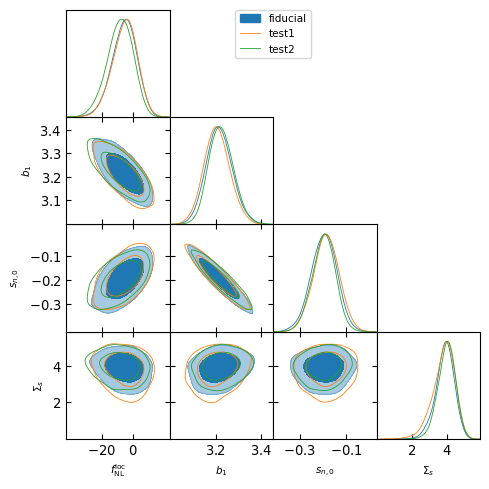

In [6]:
params = ['fnl_loc', 'QSO_ell0.b1', 'QSO_ell0.sn0', 'QSO_ell0.sigmas']
xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$']
plot_triangle(chains, params, legend_labels=['fiducial', 'test1', 'test2'], xlabels=xlabels, 
            filled=True, contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

In [7]:
for cc in chains:
    print(cc.to_stats(tablefmt="pretty"))

+-----------------+--------+--------+--------+-------+-----------------+-----------------+
|                 | argmax |  mean  | median |  std  | quantile:1sigma | interval:1sigma |
+-----------------+--------+--------+--------+-------+-----------------+-----------------+
|     fnl_loc     |  -3.7  |  -5.4  |  -4.9  |  8.0  |    -8.1/+7.8    |    -7.2/+8.7    |
|  QSO_ell0.sn0   | -0.196 | -0.196 | -0.195 | 0.056 |  -0.055/+0.055  |  -0.056/+0.054  |
|   QSO_ell0.b1   | 3.214  | 3.216  | 3.214  | 0.058 |  -0.057/+0.059  |  -0.059/+0.056  |
| QSO_ell0.sigmas |  3.98  |  3.86  |  3.90  | 0.55  |   -0.51/+0.52   |   -0.46/+0.56   |
|   QSO_ell2.b1   | 3.024  | 3.026  | 3.024  | 0.055 |  -0.053/+0.056  |  -0.055/+0.053  |
| QSO_ell2.sigmas |  3.98  |  3.86  |  3.90  | 0.55  |   -0.51/+0.52   |   -0.46/+0.56   |
+-----------------+--------+--------+--------+-------+-----------------+-----------------+
+-----------------+--------+--------+--------+-------+-----------------+-----------------+